In [11]:
import jax
print(jax.numpy)

<module 'jax.numpy' from '/home/ziq03/.local/lib/python3.10/site-packages/jax/numpy/__init__.py'>


In [1]:
import jax.numpy as jnp

In [2]:
import matplotlib.pyplot as plt

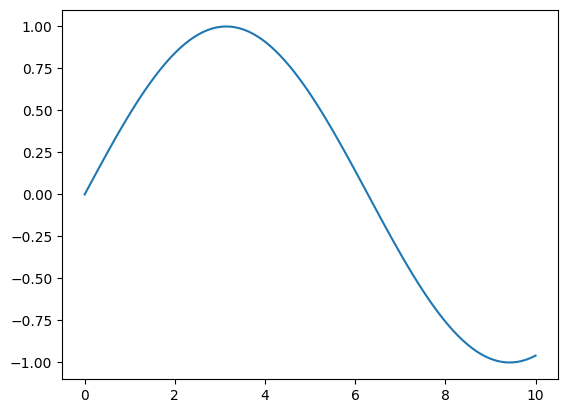

In [3]:
x_input = jnp.linspace(0,10,100)
y_output = jnp.sin(0.5*x_input)
plt.plot(x_input,y_output)

In [6]:
from jax import random

In [13]:
type(x_input)

jaxlib._jax.ArrayImpl

In [4]:
# The network is defined in terms of it's parameters 
# The key here tell us the kind of initialisation

def init_network_params(layers, keys):
    
    # We start with an empty array
    params = []
    keys = random.split(key, len(layers)-1)
    for i, (n_in ,n_out) in enumerate(zip(layers[:-1],layers[1:])):
        w_keys, b_keys = random.split(keys[i])
        
        # This splits the key function for w and b
        params.append({
        "w": random.normal(w_keys, (n_in, n_out)) * jnp.sqrt(2/n_in),# This is the He initialisation of W 
        "b": jnp.zeros((n_out,))})# This is the intialisation of b
    return params
    # As can be seen, we have initialised b to be zero. They will have non zero values at the end of the training.

In [7]:
# This is a pseudo random number generator
key = random.PRNGKey(0)

#This is our toy model to work with
params = init_network_params([1,10,10,1], key)

In [8]:
# Just like pytorch, we need a forward pass for our network
def forward(params, x):
    for layer in params[:-1]:
        # we now perform y= Wx + b
        
        x = jnp.dot(x, layer['w']) + layer['b']

        # Now we apply the acitvation function
        x = jnp.nn.tanh(x)
    final_layer = params[-1]
    # The computation of final layer is performed separately because
    # it does not involve the application of activation function.
    
    return jnp.dot(x, final_layer['w']) + final_layer(['b'])

In [9]:
#Having created the network, we define other parameters
# like the boundary value for this

#at 
x_boundary = 0
# we have
y_boundary = 1

**Now we will try to differentiate the network with respect to its input**

In [12]:
df_dx = jax.grad(forward, argnums=1)
d2f_dx2 = jax.grad(lambda p,x:df_dx(p,x))

**The loss function**

In [15]:
def pde_residual(params, x):
    # 1. Define the function for the first derivative
    # Note: argnums=1 means we differentiate w.r.t 'x'
    f_x = jax.grad(forward, argnums=1)
    
    # 2. Define the function for the second derivative
    f_xx = jax.grad(f_x, argnums=1)
    
    # We evaluate at the specific point 'x'
    return f_xx(params, x) + forward(params, x)

In [16]:
def pinn_loss(params, x_pde, x_boundary, y_boundary):
    # --- 1. PDE Loss (Physics) ---
    # We vmap the residual over the batch of interior points
    pde_res_map = jax.vmap(pde_residual, in_axes=(None, 0))
    pde_errors = pde_res_map(params, x_pde)
    mse_pde = jnp.mean(jnp.square(pde_errors))
    
    # --- 2. Boundary Loss (Data) ---
    # Ensure the model matches known values at boundaries
    boundary_preds = jax.vmap(forward, in_axes=(None, 0))(params, x_boundary)
    mse_boundary = jnp.mean(jnp.square(boundary_preds - y_boundary))
    
    # Total Loss (You can weight these with alpha/beta if needed)
    return mse_pde + mse_boundary

In [17]:
@jax.jit
def update(params, x_pde, x_boundary, y_boundary, opt_state):
    # Define a helper to compute loss and grads in one go
    def loss_fn(p):
        return pinn_loss(p, x_pde, x_boundary, y_boundary)
    
    loss_val, grads = jax.value_and_grad(loss_fn)(params)
    
    # Apply your optimizer updates here (e.g., using Optax or manual SGD)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_val

In [52]:
learning_rate = 0.01
epochs = 100
x_train = jnp.linspace(0,10,100)
params = init_network_params([1, 32, 32, 1], key)

In [53]:
for epoch in range(epochs):
    params, loss = update(params,x_train, learning_rate)
    print(f"Epoch number: {epoch} and loss: {loss}")

TypeError: update() missing 2 required positional arguments: 'y_boundary' and 'opt_state'